In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd
import seaborn as sns

from pathlib import Path

PASTA = Path.cwd()

# Leitura do arquivo
dados_consumos = pd.read_csv(PASTA.parent / "dados_brutos" / "br_mme_consumo_energia_eletrica_uf.csv.gz")

dados_consumos

,ano,mes,sigla_uf,tipo_consumo,numero_consumidores,consumo
0,2004,1,TO,Total,NaN,65876
1,2004,1,BA,Total,NaN,1444451
2,2004,1,PR,Total,NaN,1596274
3,2004,1,RS,Total,NaN,1780912
4,2004,1,GO,Total,NaN,630624
...,...,...,...,...,...,...
38875,2023,12,BA,Residencial,5932740.0,718461
38876,2023,12,PA,Residencial,2614106.0,478726
38877,2023,12,AC,Residencial,245699.0,58301
38878,2023,12,RN,Residencial,1390080.0,210119


In [2]:
# Vericação dos tipos de dados e dados ausentes
dados_consumos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38880 entries, 0 to 38879
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ano                  38880 non-null  int64  
 1   mes                  38880 non-null  int64  
 2   sigla_uf             38880 non-null  object 
 3   tipo_consumo         38880 non-null  object 
 4   numero_consumidores  25920 non-null  float64
 5   consumo              38880 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ MB


# Verificação de dados NaN na coluna numero_consumidores

Início da tratativa para identificação dos valores NaN para decisão sobre tratativa. 

In [3]:
# filtro dos dados NaN na coluna numero_consumidores
dados_com_nan = dados_consumos[dados_consumos['numero_consumidores'].isna()]

# lista de anos com numero de consumidores faltantes
dados_com_nan['ano'].unique()

array([2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

Em todos os anos presentes no dataframe há ausência de dados na coluna numero_consumidores, e em todos a mesma quantidade de dados.

In [4]:
# Verificação da quantidade NaN por ano
faltantes_ano = dados_com_nan.groupby('ano')['numero_consumidores'].apply(lambda a: a.isna().sum()).reset_index()

faltantes_ano

,ano,numero_consumidores
0,2004,648
1,2005,648
2,2006,648
3,2007,648
4,2008,648
5,2009,648
6,2010,648
7,2011,648
8,2012,648
9,2013,648


Identificação dos tipos de consumo que possuem os dados ausentes

In [5]:
# lista de tipo de consumo do dataframe completo
dados_consumos['tipo_consumo'].unique()

array(['Total', 'Cativo', 'Outros', 'Comercial', 'Industrial',
       'Residencial'], dtype=object)

In [6]:
# lista do tipo de consumo do dataframe filtrado apenas com os valores faltantes
dados_com_nan['tipo_consumo'].unique()

array(['Total', 'Cativo'], dtype=object)

Os dados apresentam categorias agregadas(Total e Cativo) com valores ausentes de número de consumidores, refletindo diferença metodológica de divulgação. Para garantir a consistência analítica, a análise concentrou-se nos tipos Comercial, Industrial, Residencial e Outros.

In [7]:
# tipos selecionados
lista_tipos_utilizados = ['Outros', 'Comercial', 'Industrial', 'Residencial']

# dataframe filtrado pelos tipos selecionados
dados_filtrados = dados_consumos[dados_consumos['tipo_consumo'].isin(lista_tipos_utilizados)]

dados_filtrados

,ano,mes,sigla_uf,tipo_consumo,numero_consumidores,consumo
648,2004,1,RN,Outros,40857.0,69617
649,2004,1,SP,Outros,311650.0,937538
650,2004,1,MS,Outros,56881.0,67601
651,2004,1,SC,Outros,226165.0,209380
652,2004,1,RJ,Outros,70634.0,416128
...,...,...,...,...,...,...
38875,2023,12,BA,Residencial,5932740.0,718461
38876,2023,12,PA,Residencial,2614106.0,478726
38877,2023,12,AC,Residencial,245699.0,58301
38878,2023,12,RN,Residencial,1390080.0,210119


# Evolução do consumo de energia ao longo dos anos

In [8]:
# Somando o consumo filtrado ao longo dos anos
evol_anos = dados_filtrados.groupby('ano')['consumo'].sum().reset_index()
evol_anos

,ano,consumo
0,2004,331864707
1,2005,345335719
2,2006,356128761
3,2007,377030014
4,2008,388472375
5,2009,384306370
6,2010,415667748
7,2011,433015628
8,2012,448126359
9,2013,463142489


O consumo de energia elétrica no brasil teve três momentos de decrescimento no Brasil como um todo
- No ano de 2009 devido à crise econômica global.
- Nos anos de 2015 e 2016 devido ao período de crise politico/econômica no Brasil.
- No ano de 2020 devido a pandemia global de Covid-19

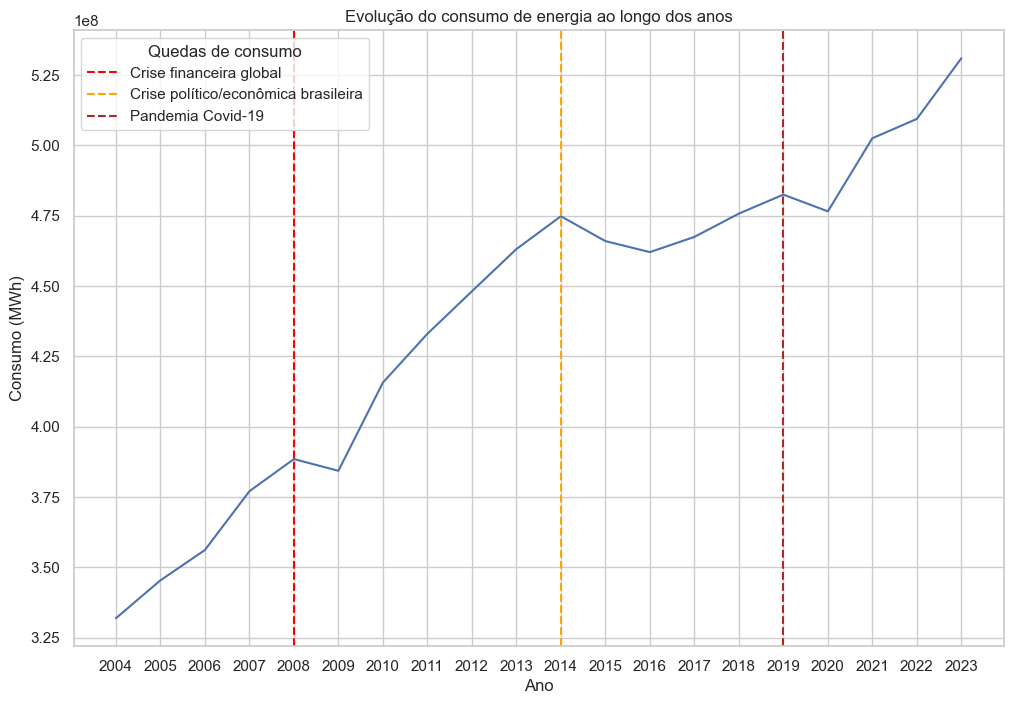

In [9]:
sns.set(style='whitegrid')

# Gráfico de linha
plt.figure(figsize=(12, 8))
sns.lineplot(
    data = evol_anos,
    x = "ano",
    y = "consumo",
)

# Títulos
plt.title("Evolução do consumo de energia ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Consumo (MWh)")

# Escala de 1 em 1 no eixo X
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))

# Linhas de referência
plt.axvline(2008, color="red", linestyle="--", label="Crise financeira global")
plt.axvline(2014, color="orange", linestyle="--", label="Crise político/econômica brasileira")
plt.axvline(2019, color="brown", linestyle="--", label="Pandemia Covid-19")

# Legenda
plt.legend(title="Quedas de consumo")

plt.show()


# Análise de cada momento crítico separadamente

Valores de contribuição acima de 100 % significam que o tipo de consumo obteve uma queda acima do total do sistema.
O valor total do sistema é compensado pelos tipos de consumo que apresetaram crescimento(percentuais negativos) nos respectivos períodos.

## Crise 2008 - 2009

In [10]:
por_tipo_antes = dados_filtrados[dados_filtrados['ano'] == 2008].groupby('tipo_consumo')['consumo'].sum().reset_index().rename(columns={'consumo': 'consumo_inicial'})

por_tipo_apos = dados_filtrados[dados_filtrados['ano'] == 2009].groupby('tipo_consumo')['consumo'].sum().reset_index().rename(columns={'consumo': 'consumo_final'})

crise_2008 = por_tipo_antes.merge(por_tipo_apos, how='inner', on='tipo_consumo')

crise_2008['delta_consumo'] = crise_2008['consumo_final'] - crise_2008['consumo_inicial']

queda_total = crise_2008['delta_consumo'].sum()

crise_2008['contribuicao'] = (crise_2008['delta_consumo'] / queda_total) * 100

crise_2008

,tipo_consumo,consumo_inicial,consumo_final,delta_consumo,contribuicao
0,Comercial,61812894,65254562,3441668,-82.613151
1,Industrial,175834053,161798656,-14035397,336.903028
2,Outros,56079045,56476982,397937,-9.552005
3,Residencial,94746383,100776170,6029787,-144.737872


C:\Users\C060419\AppData\Local\Temp\ipykernel_6356\704558720.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


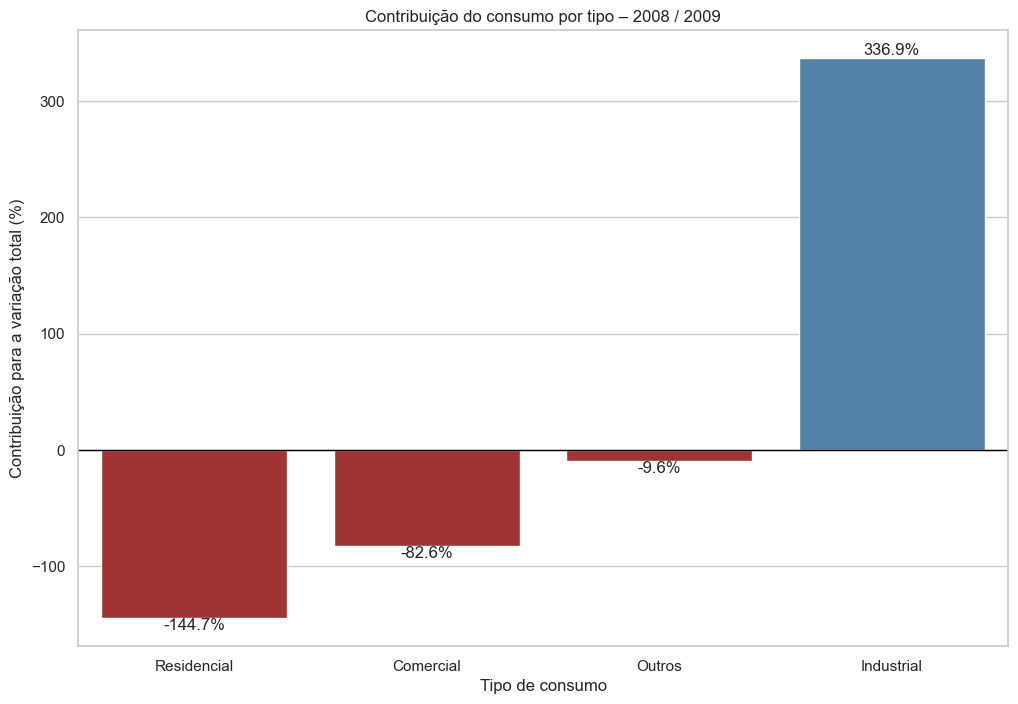

In [11]:
sns.set(style = "whitegrid")
plt.figure(figsize=(12, 8))

crise_2008_ord = crise_2008.sort_values("contribuicao")

cores = crise_2008_ord["contribuicao"].apply(
    lambda x: "firebrick" if x < 0 else "steelblue"
).to_list()

sns.barplot(
    data=crise_2008_ord,
    x = 'tipo_consumo',
    y = 'contribuicao',
    palette=cores
)

# Linha no zero (ESSENCIAL)
plt.axhline(0, color='black', linewidth=1)

for i, v in enumerate(crise_2008_ord["contribuicao"]):
    plt.text(i, v, f"{v:.1f}%", ha='center',
             va='bottom' if v > 0 else 'top')

plt.ylabel("Contribuição para a variação total (%)")
plt.xlabel("Tipo de consumo")
plt.title("Contribuição do consumo por tipo – 2008 / 2009")

plt.show()

O gráfico referente à crise de 2008 nos revela que o decrescimento de consumo de energia elétrica no Brasil foi fortemente impulsionado pelo setor Industrial tendo uma queda muito superior ao sistema. Os setores Residencial e Comercial obtiveram um comportamento anticíclico amortizando o resultado do sistema agregado. Os resultados evidenciam o forte impacto da crise financeira global no comportamento do setor Industrial, ao passo que os setores Residencial e Comercial apresentaram um comportamento anticiclico.

## Crise 2014 - 2016

In [12]:
por_tipo_antes = dados_filtrados[dados_filtrados['ano'] == 2014].groupby('tipo_consumo')['consumo'].sum().reset_index().rename(columns={'consumo': 'consumo_inicial'})

por_tipo_apos = dados_filtrados[dados_filtrados['ano'] == 2016].groupby('tipo_consumo')['consumo'].sum().reset_index().rename(columns={'consumo': 'consumo_final'})

crise_2016 = por_tipo_antes.merge(por_tipo_apos, how='inner', on='tipo_consumo')

crise_2016['delta_consumo'] = crise_2016['consumo_final'] - crise_2016['consumo_inicial']

queda_total = crise_2016['delta_consumo'].sum()

crise_2016['contribuicao'] = (crise_2016['delta_consumo'] / queda_total) * 100

crise_2016

,tipo_consumo,consumo_inicial,consumo_final,delta_consumo,contribuicao
0,Comercial,89840459,87872838,-1967621,15.426616
1,Industrial,179105677,165602857,-13502820,105.865313
2,Outros,73575466,75720956,2145490,-16.821151
3,Residencial,132301850,132872085,570235,-4.470778


C:\Users\C060419\AppData\Local\Temp\ipykernel_6356\3040499122.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


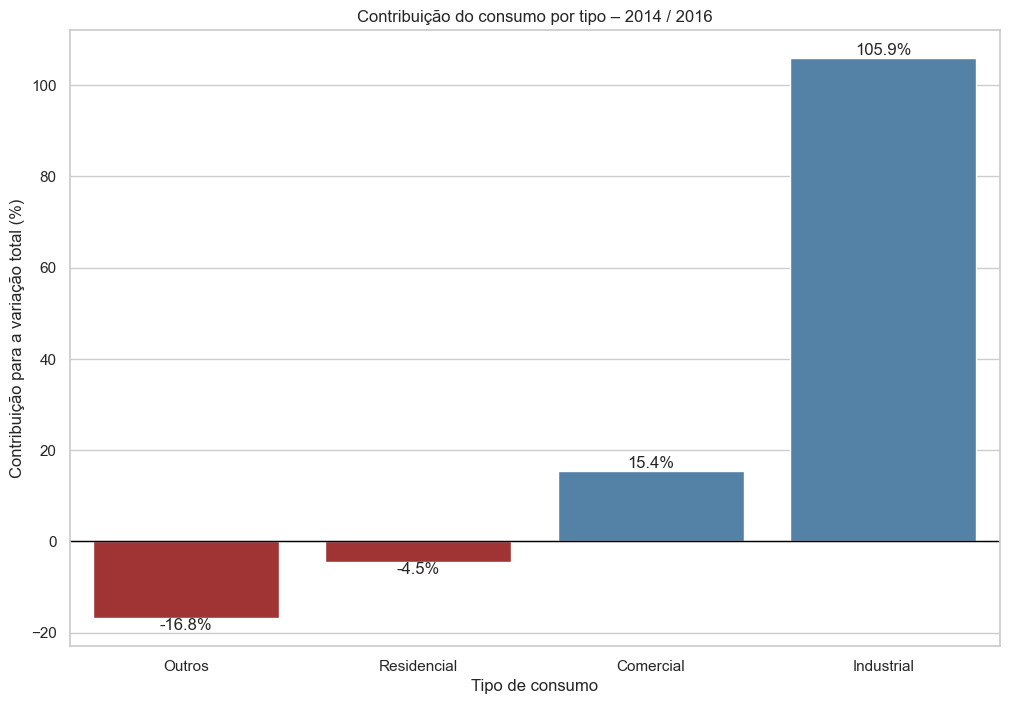

In [13]:
sns.set(style = "whitegrid")
plt.figure(figsize=(12, 8))

crise_2016_ord = crise_2016.sort_values("contribuicao")

cores = crise_2016_ord["contribuicao"].apply(
    lambda x: "firebrick" if x < 0 else "steelblue"
).to_list()

sns.barplot(
    data=crise_2016_ord,
    x = 'tipo_consumo',
    y = 'contribuicao',
    palette=cores
)

# Linha no zero (ESSENCIAL)
plt.axhline(0, color='black', linewidth=1)

for i, v in enumerate(crise_2016_ord["contribuicao"]):
    plt.text(i, v, f"{v:.1f}%", ha='center',
             va='bottom' if v > 0 else 'top')

plt.ylabel("Contribuição para a variação total (%)")
plt.xlabel("Tipo de consumo")
plt.title("Contribuição do consumo por tipo – 2014 / 2016")

plt.show()

A análise do período de 2014 a 2016 revela que a queda do consumo de energia elétrica no período foi fortemente impulsionada pelo setor Industrial com contribuição acima de 100% e pelo setor Comercial contribuindo de forma mais moderada. O setor Residencial manteve-se praticamente estável no período. Esses dados revelam que a crise teve caráter estrutural e esteve fortemente ligada a contratação de cadeia produtiva.

# Crise 2019 - 2020

In [14]:
por_tipo_antes = dados_filtrados[dados_filtrados['ano'] == 2019].groupby('tipo_consumo')['consumo'].sum().reset_index().rename(columns={'consumo': 'consumo_inicial'})

por_tipo_apos = dados_filtrados[dados_filtrados['ano'] == 2020].groupby('tipo_consumo')['consumo'].sum().reset_index().rename(columns={'consumo': 'consumo_final'})

crise_2020 = por_tipo_antes.merge(por_tipo_apos, how='inner', on='tipo_consumo')

crise_2020['delta_consumo'] = crise_2020['consumo_final'] - crise_2020['consumo_inicial']

queda_total = crise_2020['delta_consumo'].sum()

crise_2020['contribuicao'] = (crise_2020['delta_consumo'] / queda_total) * 100

crise_2020

,tipo_consumo,consumo_inicial,consumo_final,delta_consumo,contribuicao
0,Comercial,92083371,82524026,-9559345,160.742767
1,Industrial,167701054,166452179,-1248875,21.000144
2,Outros,80319895,79419094,-900801,15.147193
3,Residencial,142411004,148173042,5762038,-96.890104


C:\Users\C060419\AppData\Local\Temp\ipykernel_6356\2701203510.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


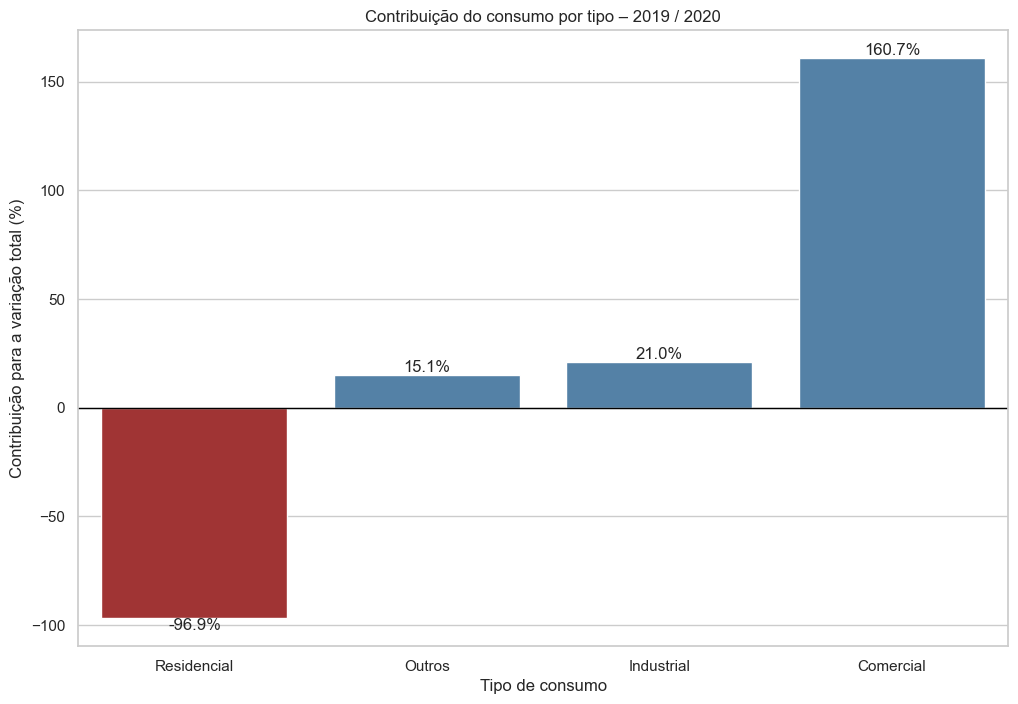

In [15]:
sns.set(style = "whitegrid")
plt.figure(figsize=(12, 8))

crise_2020_ord = crise_2020.sort_values("contribuicao")

cores = crise_2020_ord["contribuicao"].apply(
    lambda x: "firebrick" if x < 0 else "steelblue"
).to_list()

sns.barplot(
    data=crise_2020_ord,
    x = 'tipo_consumo',
    y = 'contribuicao',
    palette=cores
)

# Linha no zero (ESSENCIAL)
plt.axhline(0, color='black', linewidth=1)

for i, v in enumerate(crise_2020_ord["contribuicao"]):
    plt.text(i, v, f"{v:.1f}%", ha='center',
             va='bottom' if v > 0 else 'top')

plt.ylabel("Contribuição para a variação total (%)")
plt.xlabel("Tipo de consumo")
plt.title("Contribuição do consumo por tipo – 2019 / 2020")

plt.show()

A análise do perído de 2019 a 2020 revela que o principal contribuinte para a redução de consumo foi o setor Comercial, seguido pelos setores Industrial e Outros com menores impactos. O setor Residencial obteve um comportamento anticíclico significativo no período e foi o responsável pelo amortecimento do impacto no sistema.
O setor Comercial foi fortemente impactado pelas restrições de mobilidade e atividades presenciais nos anos 2019 a 2020, e o setor Outros, que nas análises anteriores praticamente se manteve neutro, obteve contribuição de 15,1% também impactado pelas restrições supracitadas nos setores públicos. A contra contribuição do setor Residencial foi impulsionada pelo crescimento das atividades de home-office realizadas no período.

# Conclusão

Este projeto analisou a evolução do consumo de energia elétrica no Brasil a partir de dados oficiais do setor elétrico brasileiro, com foco nas crises que causaram o decaimento do consumo anual. A análise utilizou a decomposição por setores para identificar os principais contribuintes para o decréscimo de energia em cada período.

As crises de 2008 a 2009 e as crises de 2014 a 2016 apresentaram um padrão semelhante, sendo fortemente impulsionadas pelo setor Industrial, principal impactado nas crises politico/econômicas, resultando na retração das atividades produtivas no Brasil. O setor Residencial foi um fator de compensação parcial, mostrando-se mais resilientes aos efeitos das crises político/econômica.

A crise de 2014 a 2016, em especial, teve um comportamento mais estrutural com menor capacidade de compensação dos setores. O setor Residencial permaneceu estável sem obter um comportamento contracíclico. A retração foi impulsionada pelo setor Industrial, porém o setor Comercial teve uma contribuição em menor magnitude.

Em contrapartida, a crise de 2019 a 2020 teve um comportamento divergente das crises avaliadas. O setor Comercial foi o principal contribuinte para a retração no período, o que reflete o impacto das medidas de segurança devido a pandemia de Covid-19 que impôs restrições de mobilidade e atividades presenciais. Ao mesmo tempo, o consumo residencial obteve um aumento significativo pela realocação do consumo das atividades no ambiente produtivo para o ambiente doméstico em atividades de home-office.

De forma geral, os resultado mostram que o consumo de energia elétrica reflete de maneira sensível a natureza das crises econômicas, permitindo distinguir entre choques produtivos, recessões nacionais, e restrições de mobilidade e serviços. A análise da variação de consumo de energia elétrica decomposta por tipos de consumos é uma ferramenta útil para verificar o comportamento setorial nos momentos de crise, possibilitando a geração de insights para política energética e gerenciamento de riscos.